In [1]:
"""
01: First BO loop — Expected Improvement on Branin
Goal: verify the full BO pipeline works on a standard 2D test function.
"""
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.test_functions import Branin
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use double precision (BoTorch convention; avoids GP numerical issues)
torch.set_default_dtype(torch.float64)

print('Setup OK')
print(f'PyTorch: {torch.__version__}')
print(f'Device: cpu (GP fitting is CPU-bound for small n)')

Setup OK
PyTorch: 2.12.0
Device: cpu (GP fitting is CPU-bound for small n)


In [2]:
# ============================================
# Problem definition
# ============================================
problem = Branin(negate=True)  # negate=True because BoTorch convention is MAXIMIZE
                               # Branin's true global min ≈ 0.398; we maximize -f(x)
                               # so global "max" of negated function ≈ -0.398

bounds = problem.bounds  # shape (2, 2): [[lower_x1, lower_x2], [upper_x1, upper_x2]]
d = bounds.shape[1]      # dimension = 2
optimal_value = -0.397887  # negated Branin's global max

print(f'Problem: Branin (negated for maximization)')
print(f'Dimension: {d}')
print(f'Bounds:\n{bounds}')
print(f'Optimal value (negated): {optimal_value}')

# ============================================
# Initial Latin Hypercube design
# ============================================
# Best practice for BO initial design: 2d points via LHS
from botorch.utils.sampling import draw_sobol_samples

n_init = 2 * d  # = 4 initial points

# Sobol is BoTorch's quasi-random sampler; better than uniform random for filling space
train_x = draw_sobol_samples(bounds=bounds, n=n_init, q=1).squeeze(1)
train_y = problem(train_x).unsqueeze(-1)  # shape (n_init, 1)

print(f'\nInitial design:')
print(f'X shape: {train_x.shape}')
print(f'Y shape: {train_y.shape}')
print(f'Initial best y: {train_y.max().item():.4f}')

Problem: Branin (negated for maximization)
Dimension: 2
Bounds:
tensor([[-5.,  0.],
        [10., 15.]])
Optimal value (negated): -0.397887

Initial design:
X shape: torch.Size([4, 2])
Y shape: torch.Size([4, 1])
Initial best y: -1.4197


In [3]:
# ============================================
# BO main loop with Expected Improvement
# ============================================
n_iter = 20  # number of BO iterations after initial design
best_observed = [train_y.max().item()]  # track best value over iterations

print(f'Running {n_iter} BO iterations with EI...\n')

for i in range(n_iter):
    # ---- 1. Fit GP to current data ----
    gp = SingleTaskGP(train_x, train_y)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    
    # ---- 2. Define and optimize EI acquisition ----
    EI = ExpectedImprovement(model=gp, best_f=train_y.max())
    
    candidate, acq_value = optimize_acqf(
        acq_function=EI,
        bounds=bounds,
        q=1,                # single point at a time
        num_restarts=10,    # multi-start optimization of EI
        raw_samples=64,     # initial random samples for the optimizer
    )
    
    # ---- 3. Evaluate the true function ----
    new_y = problem(candidate).unsqueeze(-1)
    
    # ---- 4. Update training data ----
    train_x = torch.cat([train_x, candidate])
    train_y = torch.cat([train_y, new_y])
    best_observed.append(train_y.max().item())
    
    # ---- 5. Log progress ----
    regret = optimal_value - best_observed[-1]
    print(f'Iter {i+1:2d}: new y = {new_y.item():.4f}, '
          f'best so far = {best_observed[-1]:.4f}, '
          f'regret = {regret:.6f}')

print(f'\n✅ Done. Final best: {best_observed[-1]:.4f}')
print(f'Final regret: {optimal_value - best_observed[-1]:.6f}')

Running 20 BO iterations with EI...

Iter  1: new y = -2.2964, best so far = -1.4197, regret = 1.021843
Iter  2: new y = -2.4991, best so far = -1.4197, regret = 1.021843
Iter  3: new y = -15.7625, best so far = -1.4197, regret = 1.021843
Iter  4: new y = -6.5535, best so far = -1.4197, regret = 1.021843
Iter  5: new y = -47.7490, best so far = -1.4197, regret = 1.021843
Iter  6: new y = -1.5768, best so far = -1.4197, regret = 1.021843
Iter  7: new y = -28.3831, best so far = -1.4197, regret = 1.021843
Iter  8: new y = -5.6074, best so far = -1.4197, regret = 1.021843
Iter  9: new y = -2.6377, best so far = -1.4197, regret = 1.021843
Iter 10: new y = -21.0057, best so far = -1.4197, regret = 1.021843
Iter 11: new y = -60.9404, best so far = -1.4197, regret = 1.021843
Iter 12: new y = -0.5539, best so far = -0.5539, regret = 0.155975
Iter 13: new y = -34.2447, best so far = -0.5539, regret = 0.155975
Iter 14: new y = -9.5326, best so far = -0.5539, regret = 0.155975
Iter 15: new y = -1

Figure saved to ../figures/01_branin_ei_baseline.png


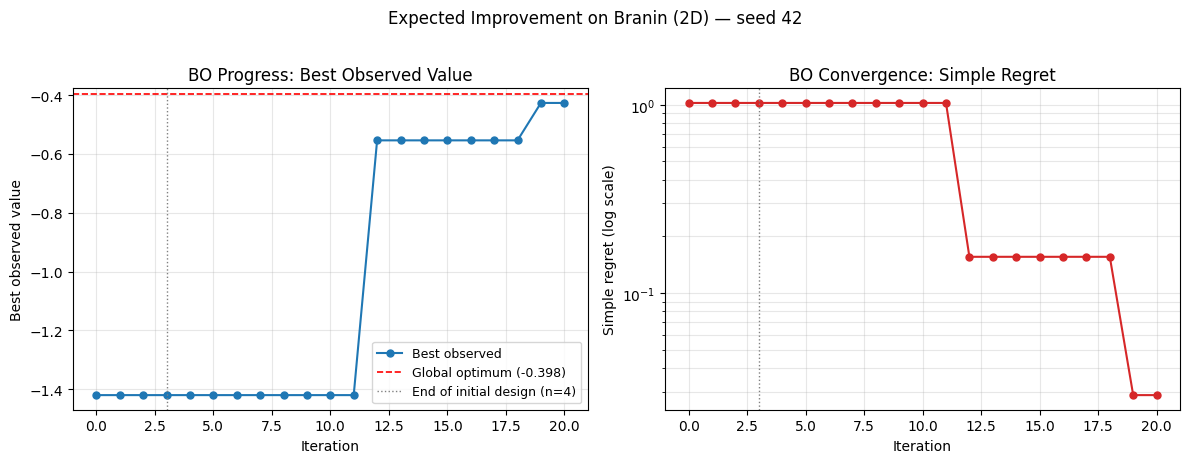

In [4]:
# ============================================
# Visualization: regret curve
# ============================================
import matplotlib.pyplot as plt

# Compute regret at each iteration (including initial)
regret_history = [optimal_value - b for b in best_observed]
iterations = list(range(len(regret_history)))  # 0 = initial design, 1-20 = BO iters

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ---- Left plot: best value over iterations ----
ax = axes[0]
ax.plot(iterations, best_observed, marker='o', markersize=5, linewidth=1.5,
        color='#1f77b4', label='Best observed')
ax.axhline(y=optimal_value, color='red', linestyle='--', linewidth=1.2,
           label=f'Global optimum ({optimal_value:.3f})')
ax.axvline(x=n_init - 1, color='gray', linestyle=':', linewidth=1,
           label=f'End of initial design (n={n_init})')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best observed value')
ax.set_title('BO Progress: Best Observed Value')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# ---- Right plot: regret in log scale ----
ax = axes[1]
ax.plot(iterations, regret_history, marker='o', markersize=5, linewidth=1.5,
        color='#d62728')
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel('Simple regret (log scale)')
ax.set_title('BO Convergence: Simple Regret')
ax.grid(True, alpha=0.3, which='both')
ax.axvline(x=n_init - 1, color='gray', linestyle=':', linewidth=1)

plt.suptitle('Expected Improvement on Branin (2D) — seed 42', y=1.02, fontsize=12)
plt.tight_layout()

# Save figure for the project
import os
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/01_branin_ei_baseline.png', dpi=150, bbox_inches='tight')
print(f'Figure saved to ../figures/01_branin_ei_baseline.png')

plt.show()

In [5]:
# ============================================
# Save experiment metadata + results
# ============================================
import json
import os
from datetime import datetime

# Build a results dict
result = {
    'experiment_name': '01_branin_ei_baseline',
    'timestamp': datetime.now().isoformat(),
    'problem': 'Branin',
    'dimension': d,
    'acquisition': 'EI',
    'surrogate': 'SingleTaskGP',
    'seed': SEED,
    'n_init': n_init,
    'n_iter': n_iter,
    'best_observed': best_observed,
    'regret_history': regret_history,
    'final_best': best_observed[-1],
    'final_regret': float(optimal_value - best_observed[-1]),
    'optimal_value': optimal_value,
}

# Save to results/
os.makedirs('../results', exist_ok=True)
results_path = '../results/01_branin_ei_baseline.json'
with open(results_path, 'w') as f:
    json.dump(result, f, indent=2)

print(f'Results saved to {results_path}')
print(f'\n--- Summary ---')
print(f'Problem:       {result["problem"]} ({d}D)')
print(f'Acquisition:   {result["acquisition"]}')
print(f'Iterations:    {result["n_iter"]}')
print(f'Final regret:  {result["final_regret"]:.6f}')
print(f'\n✅ Notebook complete.')

Results saved to ../results/01_branin_ei_baseline.json

--- Summary ---
Problem:       Branin (2D)
Acquisition:   EI
Iterations:    20
Final regret:  0.028791

✅ Notebook complete.
